# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs

Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus




### **Libraries**

In [1]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
import ast
from collections import Counter
import seaborn as sns
import shutil
import glob
from tqdm import tqdm
from PIL import Image
import pickle
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

warnings.filterwarnings('ignore')

### **Initial Loading and Simple Preprocessing**

In [6]:
meta_data = pd.read_csv('../input/dataset/metadata.csv')
meta_data['category'] = meta_data['category'].str.replace(" ", ",").apply(ast.literal_eval)
meta_data = meta_data.dropna(subset=['tissue'])

meta_data['fold'] = meta_data['file_path'].str[5]
meta_data['file_path'] = meta_data['file_path'].str[:-10]

tissue_mapping = {
    0: "Adrenal Gland",
    1: "Bile Duct",
    2: "Bladder",
    3: "Breast",
    4: "Cervix",
    5: "Colon",
    6: "Esophagus",
    7: "Head & Neck",
    8: "Kidney",
    9: "Liver",
    10: "Lung",
    11: "Ovarian",
    12: "Pancreatic",
    13: "Prostate",
    14: "Skin",
    15: "Stomach",
    16: "Testis",
    17: "Thyroid",
    18: "Uterus"
}

meta_data['tissue_labels'] = meta_data['tissue'].astype(int).map(tissue_mapping)

meta_data.sample(5)

,file_path,category,tissue,fold,tissue_labels
5964,fold_3/sample_785,"[1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",5,3,Colon
7641,fold_3/sample_2462,[1],16,3,Testis
5243,fold_3/sample_64,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, ...",3,3,Breast
1542,fold_1/sample_1542,"[4, 4, 4]",0,1,Adrenal Gland
6194,fold_3/sample_1015,"[1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",17,3,Thyroid


#### **Extracting Category-Grouped Cells**

In [7]:
neoplastic_cells_df = meta_data[meta_data['category'].apply(lambda x: 0 in x)]
inflammatory_cells_df = meta_data[meta_data['category'].apply(lambda x: 1 in x)]
connective_cells_df = meta_data[meta_data['category'].apply(lambda x: 2 in x)]
dead_cells_df = meta_data[meta_data['category'].apply(lambda x: 3 in x)]
epithelial_cells_df = meta_data[meta_data['category'].apply(lambda x: 4 in x)]

neoplastic_cells_df.to_csv('neoplastic_cells_df.csv', index=False)
inflammatory_cells_df.to_csv('inflammatory_cells_df.csv', index=False)
connective_cells_df.to_csv('connective_cells_df.csv', index=False)
dead_cells_df.to_csv('dead_cells_df.csv', index=False)
epithelial_cells_df.to_csv('epithelial_cells_df.csv', index=False)

dead_cells_df.head()

,file_path,category,tissue,fold,tissue_labels
178,fold_1/sample_178,"[1, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",3,1,Breast
776,fold_1/sample_776,"[1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3]",5,1,Colon
782,fold_1/sample_782,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",5,1,Colon
784,fold_1/sample_784,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,1,Colon
790,fold_1/sample_790,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,1,Colon


#### **Merging Masks**

In [8]:
def load_images_and_merge_masks(dataset_path, df, category = 3):
    image_mask_dict = {}  

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Samples"):
        sample_path = os.path.join(dataset_path, row["file_path"])

        image_path = os.path.join(sample_path, "image.png")
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue
        image = cv2.imread(image_path)  

        mask_dir = os.path.join(sample_path, "masks")
        if not os.path.exists(mask_dir):
            print(f"Mask directory not found: {mask_dir}")
            continue

        merged_mask = None
        for mask_filename in os.listdir(mask_dir):
            if mask_filename.startswith(f"mask_{category}_"):  
                mask_path = os.path.join(mask_dir, mask_filename)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  

                if merged_mask is None:
                    merged_mask = mask  
                else:
                    merged_mask = cv2.bitwise_or(merged_mask, mask)  

        if merged_mask is not None:
            image_mask_dict[sample_path] = (image, merged_mask)  

    return image_mask_dict

In [19]:
DATASET_PATH = "../input/dataset"

dead_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, dead_cells_df, 3)

if True:
    neoplastic_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, neoplastic_cells_df, 0)
    inflammatory_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, inflammatory_cells_df, 1)
    connective_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, connective_cells_df, 2)
    epithelial_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, epithelial_cells_df, 4)

Processing Samples: 100%|██████████| 1528/1528 [01:46<00:00, 14.39it/s]


#### **Shifting Dataset to HuggingFace**

In [ ]:
from huggingface_hub import HfApi, login

login(token="")

repo_name = "ahmedembedded/PanNuke"
api = HfApi()
api.create_repo(repo_name, repo_type="dataset", exist_ok=True)

RepoUrl('https://huggingface.co/datasets/ahmedembedded/PanNuke', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ahmedembedded/PanNuke')

In [29]:
import numpy as np
import os
from huggingface_hub import HfApi

def save_numpy_arrays(image_mask_dict, save_path):
    images = []
    masks = []
    paths = []

    for path, (image, mask) in image_mask_dict.items():
        images.append(np.array(image, dtype=np.uint8))  # Ensure it's a NumPy array
        masks.append(np.array(mask, dtype=np.uint8))
        paths.append(path)

    np.savez_compressed(save_path, image_paths=paths, images=np.array(images), masks=np.array(masks))

os.makedirs("numpy_dataset", exist_ok=True)

save_numpy_arrays(dead_image_mask_dict, "numpy_dataset/dead_cells.npz")
save_numpy_arrays(neoplastic_image_mask_dict, "numpy_dataset/neoplastic_cells.npz")
save_numpy_arrays(inflammatory_image_mask_dict, "numpy_dataset/inflammatory_cells.npz")
save_numpy_arrays(connective_image_mask_dict, "numpy_dataset/connective_cells.npz")
save_numpy_arrays(epithelial_image_mask_dict, "numpy_dataset/epithelial_cells.npz")

repo_name = "ahmedembedded/PanNuke"
api = HfApi()
api.create_repo(repo_name, repo_type="dataset", exist_ok=True)

for file_name in os.listdir("numpy_dataset"):
    api.upload_file(
        path_or_fileobj=f"numpy_dataset/{file_name}",
        path_in_repo=file_name,
        repo_id=repo_name,
        repo_type="dataset",
    )

print("Dataset successfully uploaded to Hugging Face!")

connective_cells.npz:   0%|          | 0.00/1.04G [00:00<?, ?B/s]

dead_cells.npz:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

epithelial_cells.npz:   0%|          | 0.00/254M [00:00<?, ?B/s]

inflammatory_cells.npz:   0%|          | 0.00/709M [00:00<?, ?B/s]

neoplastic_cells.npz:   0%|          | 0.00/723M [00:00<?, ?B/s]

Dataset successfully uploaded to Hugging Face!


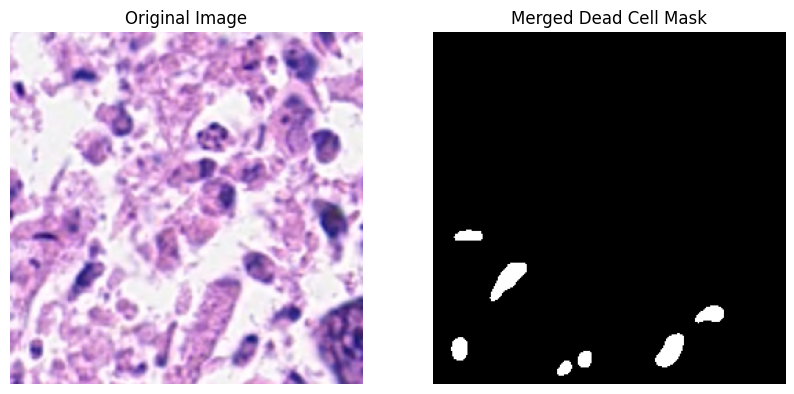

In [41]:
if dead_image_mask_dict:
    sample_path = '../input/dataset/fold_1/sample_776'
    (sample_image, sample_mask) = dead_image_mask_dict[sample_path]
    
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))  
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(sample_mask, cmap="gray")  
    plt.title("Merged Dead Cell Mask")
    plt.axis("off")

    plt.show()